# HMDA 2024 Responsible ML Capstone

## 1. Responsible ML Framing

This notebook studies a binary prediction task using HMDA 2024 loan application data: approve (`action_taken` in `1`, `2`) versus deny (`action_taken` equal to `3`). The model is intended to support loan approval decisions, so the system context is not purely technical; these decisions affect access to credit and can create meaningful financial and social consequences.

**Stakeholders:** loan applicants, financial institutions, and regulators.

**Conflicting interests:** lenders want efficient and accurate decisions with controlled risk, applicants want fair access to credit and protection from unjust denial, and regulators want compliance, transparency, and non-discrimination.

**Risk vs benefit:** a useful model can improve consistency and provide a reproducible benchmark for approval decisions, but a poor model can deny credit unfairly, amplify disparities across groups, and create regulatory or reputational harm.

**Failure definition:** failure means more than low predictive quality. It also includes unfair subgroup behavior, excessive harmful errors, or a decision process that benefits institutions while disproportionately harming applicants.

**What are we optimizing?** This notebook does not optimize for accuracy alone. The objective is to balance predictive performance, with `AUC` as a core metric, against fairness across demographic groups.

**Who benefits vs who is harmed?** A better model may help institutions make more consistent decisions and may benefit applicants if errors and disparities are reduced. A worse model can especially harm applicants who are wrongly denied and can expose institutions to fairness and compliance risk.

## Data Requirement Note

Place `2024_lar.zip` in the project root before running this notebook. The notebook assumes local file access and does not download the raw HMDA archive automatically.

## 2. Environment and Imports

This section imports the libraries used in the notebook and defines the paths for the raw HMDA archive, extracted text file, and filtered parquet dataset.

In [ ]:
%pip install duckdb
from pathlib import Path
from zipfile import ZipFile

import duckdb
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Define the project paths used throughout the notebook.
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
ZIP_PATH = PROJECT_ROOT / "2024_lar.zip"
TXT_PATH = PROJECT_ROOT / "2024_lar.txt"
PARQUET_PATH = DATA_DIR / "hmda_filtered.parquet"
RAW_MEMBER_NAME = "2024_lar.txt"

DATA_DIR.mkdir(parents=True, exist_ok=True)

# Extract the raw text file only if it is not already available locally.
if not TXT_PATH.exists():
    if not ZIP_PATH.exists():
        raise FileNotFoundError("Expected either 2024_lar.txt or 2024_lar.zip in the project root.")
    print("Extracting 2024_lar.txt from the zip archive. This can take a while on the first run...")
    with ZipFile(ZIP_PATH) as zf:
        zf.extract(RAW_MEMBER_NAME, path=PROJECT_ROOT)

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw HMDA text file: {TXT_PATH}")
print(f"Filtered parquet output: {PARQUET_PATH}")

Project root: c:\Users\srako\Desktop\Classes\rML\Capstone\Responsible_ML_Capstone
Raw HMDA text file: c:\Users\srako\Desktop\Classes\rML\Capstone\Responsible_ML_Capstone\2024_lar.txt
Filtered parquet output: c:\Users\srako\Desktop\Classes\rML\Capstone\Responsible_ML_Capstone\data\hmda_filtered.parquet


## 3. Data Source and Problem Framing

This notebook uses the 2024 HMDA Loan/Application Register data. The prediction task is binary classification: approve (`action_taken` in `1`, `2`) versus deny (`action_taken` equal to `3`). The model is meant to support approval decisions, not to predict default risk or later loan performance.

Reference pages:
- [HMDA 2024 dynamic national loan-level dataset](https://ffiec.cfpb.gov/data-publication/dynamic-national-loan-level-dataset/2024)
- [HMDA loan/application register data fields documentation](https://ffiec.cfpb.gov/documentation/publications/loan-level-datasets/lar-data-fields)

## 4. Raw Data Inspection with DuckDB

DuckDB is used to inspect the raw pipe-delimited HMDA file before filtering so the notebook works from the actual schema and field names.

In [2]:
def sql_path(path: Path) -> str:
    return path.as_posix().replace("'", "''")

con = duckdb.connect()

# Preview the raw schema directly from the HMDA text file.
schema_preview = con.execute(
    f"""
    DESCRIBE SELECT *
    FROM read_csv_auto(
        '{sql_path(TXT_PATH)}',
        delim='|',
        header=True,
        sample_size=20000
    )
    """
).df()

display(schema_preview.head(25))
print(f"Total number of columns in the raw HMDA file: {len(schema_preview)}")

,column_name,column_type,null,key,default,extra
0,activity_year,BIGINT,YES,None,None,None
1,lei,VARCHAR,YES,None,None,None
2,derived_msa_md,BIGINT,YES,None,None,None
3,state_code,VARCHAR,YES,None,None,None
4,county_code,VARCHAR,YES,None,None,None
5,census_tract,VARCHAR,YES,None,None,None
6,conforming_loan_limit,VARCHAR,YES,None,None,None
7,derived_loan_product_type,VARCHAR,YES,None,None,None
8,derived_dwelling_category,VARCHAR,YES,None,None,None
9,derived_ethnicity,VARCHAR,YES,None,None,None


Total number of columns in the raw HMDA file: 99


## 5. Filter and Export a Smaller Dataset

This step keeps only the rows and columns needed for the modeling workflow and saves the result as `data/hmda_filtered.parquet` for reuse.

In [3]:
selected_columns = [
    "action_taken",
    "property_value",
    "income",
    "tract_population",
    "tract_minority_population_percent",
    "ffiec_msa_md_median_family_income",
    "tract_to_msa_income_percentage",
    "state_code",
    "derived_loan_product_type",
    "derived_dwelling_category",
    "loan_purpose",
    "lien_status",
    "occupancy_type",
    "applicant_age",
    "derived_race",
    "derived_sex",
    "derived_ethnicity",
]

selected_columns_sql = ",\n        ".join(selected_columns)

# Create a smaller parquet dataset that keeps only the baseline modeling fields.
con.execute(
    f"""
    COPY (
        SELECT
            {selected_columns_sql}
        FROM read_csv_auto(
            '{sql_path(TXT_PATH)}',
            delim='|',
            header=True,
            all_varchar=True,
            sample_size=20000
        )
        WHERE action_taken IN ('1', '2', '3')
          AND derived_sex IN ('Male', 'Female')
    ) TO '{sql_path(PARQUET_PATH)}' (FORMAT PARQUET)
    """
)

filtered_schema = con.execute(
    f"DESCRIBE SELECT * FROM read_parquet('{sql_path(PARQUET_PATH)}')"
).df()
filtered_row_count = con.execute(
    f"SELECT COUNT(*) AS row_count FROM read_parquet('{sql_path(PARQUET_PATH)}')"
).fetchone()[0]
filtered_column_count = len(filtered_schema)

print(f"Filtered parquet written to: {PARQUET_PATH}")
print(f"Rows kept for modeling: {filtered_row_count:,}")
print(f"Total number of columns in the filtered dataset: {filtered_column_count}")
print(f"Total number of rows in the filtered dataset: {filtered_row_count:,}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Filtered parquet written to: c:\Users\srako\Desktop\Classes\rML\Capstone\Responsible_ML_Capstone\data\hmda_filtered.parquet
Rows kept for modeling: 4,886,499
Total number of columns in the filtered dataset: 17
Total number of rows in the filtered dataset: 4,886,499


## 6. Load the Filtered Data into pandas

The parquet file becomes the main analysis dataset for the rest of the notebook. This section loads it into pandas, previews a few rows, shows the dataset size, and exports a small CSV preview.

In [4]:
df = pd.read_parquet(PARQUET_PATH)
preview_csv_path = DATA_DIR / "hmda_filtered_preview.csv"
preview_rows = 20

print("Parquet is the main dataset used for the remaining analysis steps in this notebook.")

dataset_size = pd.Series(
    {
        "rows": df.shape[0],
        "columns": df.shape[1],
    }
).to_frame("value")

print(f"Filtered dataframe shape: {df.shape}")
display(dataset_size)
display(df.head())
display(pd.Series(df.columns, name="column_name").to_frame())

# Save a tiny CSV sample for quick inspection outside the notebook.
preview_df = df.head(preview_rows).copy()
preview_df.to_csv(preview_csv_path, index=False)
print(f"Exported a {preview_rows}-row CSV preview to: {preview_csv_path}")

missing_summary = (
    df.isna()
    .mean()
    .sort_values(ascending=False)
    .mul(100)
    .round(2)
    .rename("missing_pct")
    .to_frame()
)

display(missing_summary.head(10))

Parquet is the main dataset used for the remaining analysis steps in this notebook.
Filtered dataframe shape: (4886499, 17)


,value
rows,4886499
columns,17


,action_taken,property_value,income,tract_population,tract_minority_population_percent,ffiec_msa_md_median_family_income,tract_to_msa_income_percentage,state_code,derived_loan_product_type,derived_dwelling_category,loan_purpose,lien_status,occupancy_type,applicant_age,derived_race,derived_sex,derived_ethnicity
0,1,285000,97,2528,5.26,81800,117.0,IN,VA:First Lien,Single Family (1-4 Units):Manufactured,1,1,1,25-34,White,Male,Not Hispanic or Latino
1,1,425000,73,7516,50.68,90400,123.0,FL,FHA:First Lien,Single Family (1-4 Units):Site-Built,32,1,1,45-54,White,Female,Hispanic or Latino
2,3,185000,55,3329,93.03,100900,45.0,GA,FHA:First Lien,Single Family (1-4 Units):Site-Built,1,1,1,45-54,Black or African American,Female,Not Hispanic or Latino
3,1,575000,133,5513,27.14,117400,111.0,NJ,Conventional:First Lien,Single Family (1-4 Units):Site-Built,1,1,1,55-64,Black or African American,Male,Not Hispanic or Latino
4,1,455000,97,2144,71.41,110300,93.0,TX,Conventional:First Lien,Single Family (1-4 Units):Site-Built,1,1,1,35-44,Asian,Male,Not Hispanic or Latino


,column_name
0,action_taken
1,property_value
2,income
3,tract_population
4,tract_minority_population_percent
5,ffiec_msa_md_median_family_income
6,tract_to_msa_income_percentage
7,state_code
8,derived_loan_product_type
9,derived_dwelling_category


Exported a 20-row CSV preview to: c:\Users\srako\Desktop\Classes\rML\Capstone\Responsible_ML_Capstone\data\hmda_filtered_preview.csv


,missing_pct
action_taken,0.0
property_value,0.0
income,0.0
tract_population,0.0
tract_minority_population_percent,0.0
ffiec_msa_md_median_family_income,0.0
tract_to_msa_income_percentage,0.0
state_code,0.0
derived_loan_product_type,0.0
derived_dwelling_category,0.0


## 7. Label Creation

`action_taken` is converted into a binary target: approve (`1`, `2`) versus deny (`3`). This creates the label used for modeling.

In [5]:
label_map = {"1": 1, "2": 1, "3": 0}

# Map HMDA action outcomes into the binary baseline target.
df["label"] = df["action_taken"].map(label_map)
df = df.dropna(subset=["label"]).copy()
df["label"] = df["label"].astype(int)

display(df[["action_taken", "label"]].head())
display(df["label"].value_counts().rename_axis("label").to_frame("count"))
display(df["label"].value_counts(normalize=True).rename_axis("label").to_frame("share").round(4))

,action_taken,label
0,1,1
1,1,1
2,3,0
3,1,1
4,1,1


,count
label,
1,3539072
0,1347427


,share
label,
1,0.7243
0,0.2757


## 8. Feature Selection

The model uses a compact set of numeric and categorical features, while `derived_race`, `derived_sex`, and `derived_ethnicity` are kept only for subgroup analysis and not used as training inputs.

In [6]:
fairness_group_columns = ["derived_race", "derived_sex", "derived_ethnicity"]

numeric_features = [
    "property_value",
    "income",
    "tract_population",
    "tract_minority_population_percent",
    "ffiec_msa_md_median_family_income",
    "tract_to_msa_income_percentage",
]

categorical_features = [
    "state_code",
    "derived_loan_product_type",
    "derived_dwelling_category",
    "loan_purpose",
    "lien_status",
    "occupancy_type",
    "applicant_age",
]

# Keep protected attributes for later fairness evaluation, but exclude them from training.
model_features = numeric_features + categorical_features

required_columns = model_features + fairness_group_columns + ["label"]
missing_columns = sorted(set(required_columns) - set(df.columns))
if missing_columns:
    raise ValueError(f"Missing expected columns: {missing_columns}")

feature_summary = pd.DataFrame(
    {
        "feature": numeric_features + categorical_features + fairness_group_columns,
        "role": (
            ["numeric feature"] * len(numeric_features)
            + ["categorical feature"] * len(categorical_features)
            + ["fairness grouping column"] * len(fairness_group_columns)
        ),
    }
)

display(feature_summary)

,feature,role
0,property_value,numeric feature
1,income,numeric feature
2,tract_population,numeric feature
3,tract_minority_population_percent,numeric feature
4,ffiec_msa_md_median_family_income,numeric feature
5,tract_to_msa_income_percentage,numeric feature
6,state_code,categorical feature
7,derived_loan_product_type,categorical feature
8,derived_dwelling_category,categorical feature
9,loan_purpose,categorical feature


## 9. Data Cleaning and Preprocessing

This section keeps the required columns, converts numeric-looking fields to numeric format, standardizes common missing-value tokens, and defines the numeric and categorical preprocessing pipeline.

In [7]:
model_df = df[required_columns].copy()

missing_tokens = {"NA": np.nan, "Exempt": np.nan, "": np.nan}

# Standardize placeholder strings before fitting the preprocessing pipeline.
for column in numeric_features:
    model_df[column] = pd.to_numeric(model_df[column].replace(missing_tokens), errors="coerce")

for column in categorical_features + fairness_group_columns:
    model_df[column] = model_df[column].replace(missing_tokens)

X = model_df[model_features]
y = model_df["label"]

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

display(model_df[required_columns].head())

,property_value,income,tract_population,tract_minority_population_percent,ffiec_msa_md_median_family_income,tract_to_msa_income_percentage,state_code,derived_loan_product_type,derived_dwelling_category,loan_purpose,lien_status,occupancy_type,applicant_age,derived_race,derived_sex,derived_ethnicity,label
0,285000.0,97.0,2528,5.26,81800,117.0,IN,VA:First Lien,Single Family (1-4 Units):Manufactured,1,1,1,25-34,White,Male,Not Hispanic or Latino,1
1,425000.0,73.0,7516,50.68,90400,123.0,FL,FHA:First Lien,Single Family (1-4 Units):Site-Built,32,1,1,45-54,White,Female,Hispanic or Latino,1
2,185000.0,55.0,3329,93.03,100900,45.0,GA,FHA:First Lien,Single Family (1-4 Units):Site-Built,1,1,1,45-54,Black or African American,Female,Not Hispanic or Latino,0
3,575000.0,133.0,5513,27.14,117400,111.0,NJ,Conventional:First Lien,Single Family (1-4 Units):Site-Built,1,1,1,55-64,Black or African American,Male,Not Hispanic or Latino,1
4,455000.0,97.0,2144,71.41,110300,93.0,TX,Conventional:First Lien,Single Family (1-4 Units):Site-Built,1,1,1,35-44,Asian,Male,Not Hispanic or Latino,1


## 10. Train and Test Split

The data is split into training and test sets with `random_state=42` and stratification on the label so the approval-denial balance stays stable across both splits.

In [8]:
# Use a stratified split so the approval rate stays stable across train and test sets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

split_summary = pd.Series(
    {
        "train_rows": len(X_train),
        "test_rows": len(X_test),
        "train_positive_rate": y_train.mean(),
        "test_positive_rate": y_test.mean(),
    }
).to_frame("value")

display(split_summary.round(4))

,value
train_rows,3.909199e+06
test_rows,9.773000e+05
train_positive_rate,7.243000e-01
test_positive_rate,7.243000e-01


## 11. Baseline Model

This section fits `LogisticRegression(max_iter=1000)` as the baseline model.

In [9]:
# Fit logistic regression as the baseline model.
baseline_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000)),
    ]
)

baseline_pipeline.fit(X_train, y_train)
baseline_pipeline

,steps,"[('preprocess', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 12. Evaluation

This section reports a compact baseline summary using `accuracy`, `AUC`, `log-loss`, `precision`, `recall`, and a small `FPR` table.

In [10]:
# Baseline evaluation metrics.
y_pred_baseline = baseline_pipeline.predict(X_test)
y_score_baseline = baseline_pipeline.predict_proba(X_test)[:, 1]

baseline_cm = confusion_matrix(y_test, y_pred_baseline, labels=[0, 1])
baseline_tn, baseline_fp, baseline_fn, baseline_tp = baseline_cm.ravel()
baseline_fpr = baseline_fp / (baseline_fp + baseline_tn) if (baseline_fp + baseline_tn) else np.nan

baseline_performance_metrics = pd.Series(
    {
        "accuracy": accuracy_score(y_test, y_pred_baseline),
        "auc": roc_auc_score(y_test, y_score_baseline),
        "log_loss": log_loss(y_test, y_score_baseline),
        "precision": precision_score(y_test, y_pred_baseline),
        "recall": recall_score(y_test, y_pred_baseline),
    }
).round(4).to_frame("value")

baseline_fpr_metrics = pd.Series(
    {
        "overall_fpr": baseline_fpr,
    }
).round(4).to_frame("value")

display(baseline_performance_metrics)
display(baseline_fpr_metrics)

,value
accuracy,0.7417
auc,0.7406
log_loss,0.5161
precision,0.7613
recall,0.9373


,value
overall_fpr,0.7721


This subgroup evaluation is included as an early diagnostic view of baseline model behavior across groups. At this stage, it is not a formal fairness assessment and should not be treated as a final fairness conclusion.

## 13. Main Model: XGBoost

This section fits `XGBClassifier(random_state=42)` as the main model and reports the same compact evaluation metrics used for the logistic regression baseline.

In [11]:
xgb_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        (
            "classifier",
            XGBClassifier(
                n_estimators=200,
                max_depth=6,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

# Use XGBoost as the main model pipeline.
model = xgb_pipeline
model.fit(X_train, y_train)

display(model)

y_pred = model.predict(X_test)
y_score = model.predict_proba(X_test)[:, 1]

main_cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
main_tn, main_fp, main_fn, main_tp = main_cm.ravel()
main_fpr = main_fp / (main_fp + main_tn) if (main_fp + main_tn) else np.nan

main_performance_metrics = pd.Series(
    {
        "accuracy": accuracy_score(y_test, y_pred),
        "auc": roc_auc_score(y_test, y_score),
        "log_loss": log_loss(y_test, y_score),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
    }
).round(4).to_frame("value")

main_fpr_metrics = pd.Series(
    {
        "overall_fpr": main_fpr,
    }
).round(4).to_frame("value")

display(main_performance_metrics)
display(main_fpr_metrics)

,steps,"[('preprocess', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


,value
accuracy,0.7837
auc,0.8003
log_loss,0.4627
precision,0.8007
recall,0.9338


,value
overall_fpr,0.6106


## 14. Second Model: Random Forest

This section fits `RandomForestClassifier(random_state=42)` as a second comparison model. It reuses the existing train/test split and preprocessing output, then reports the same compact evaluation metrics and a three-model comparison table.

In [12]:
# Reuse the fitted preprocessing step from the main model pipeline without building a separate pipeline.
rf_preprocessor = model.named_steps["preprocess"]
X_train_rf = rf_preprocessor.transform(X_train)
X_test_rf = rf_preprocessor.transform(X_test)

# Keep the random forest lighter so it remains practical on the full HMDA training set.
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    min_samples_leaf=25,
    max_features="sqrt",
    max_samples=0.1,
    random_state=42,
    n_jobs=-1,
)
rf_model.fit(X_train_rf, y_train)

y_pred_rf = rf_model.predict(X_test_rf)
y_score_rf = rf_model.predict_proba(X_test_rf)[:, 1]

rf_cm = confusion_matrix(y_test, y_pred_rf, labels=[0, 1])
rf_tn, rf_fp, rf_fn, rf_tp = rf_cm.ravel()
rf_fpr = rf_fp / (rf_fp + rf_tn) if (rf_fp + rf_tn) else np.nan

rf_performance_metrics = pd.Series(
    {
        "accuracy": accuracy_score(y_test, y_pred_rf),
        "auc": roc_auc_score(y_test, y_score_rf),
        "log_loss": log_loss(y_test, y_score_rf),
        "precision": precision_score(y_test, y_pred_rf),
        "recall": recall_score(y_test, y_pred_rf),
    }
).round(4).to_frame("value")

rf_fpr_metrics = pd.Series(
    {
        "overall_fpr": rf_fpr,
    }
).round(4).to_frame("value")

display(rf_performance_metrics)
display(rf_fpr_metrics)

comparison_df = pd.DataFrame(
    [
        {
            "model": "Logistic Regression",
            "accuracy": baseline_performance_metrics.loc["accuracy", "value"],
            "auc": baseline_performance_metrics.loc["auc", "value"],
            "log_loss": baseline_performance_metrics.loc["log_loss", "value"],
            "precision": baseline_performance_metrics.loc["precision", "value"],
            "recall": baseline_performance_metrics.loc["recall", "value"],
            "fpr": baseline_fpr_metrics.loc["overall_fpr", "value"],
        },
        {
            "model": "XGBoost",
            "accuracy": main_performance_metrics.loc["accuracy", "value"],
            "auc": main_performance_metrics.loc["auc", "value"],
            "log_loss": main_performance_metrics.loc["log_loss", "value"],
            "precision": main_performance_metrics.loc["precision", "value"],
            "recall": main_performance_metrics.loc["recall", "value"],
            "fpr": main_fpr_metrics.loc["overall_fpr", "value"],
        },
        {
            "model": "Random Forest",
            "accuracy": rf_performance_metrics.loc["accuracy", "value"],
            "auc": rf_performance_metrics.loc["auc", "value"],
            "log_loss": rf_performance_metrics.loc["log_loss", "value"],
            "precision": rf_performance_metrics.loc["precision", "value"],
            "recall": rf_performance_metrics.loc["recall", "value"],
            "fpr": rf_fpr_metrics.loc["overall_fpr", "value"],
        },
    ]
).set_index("model").round(4)

display(comparison_df)

,value
accuracy,0.7653
auc,0.7792
log_loss,0.4877
precision,0.7695
recall,0.9650


,value
overall_fpr,0.7594


,accuracy,auc,log_loss,precision,recall,fpr
model,,,,,,
Logistic Regression,0.7417,0.7406,0.5161,0.7613,0.9373,0.7721
XGBoost,0.7837,0.8003,0.4627,0.8007,0.9338,0.6106
Random Forest,0.7653,0.7792,0.4877,0.7695,0.9650,0.7594


## 15. Lecture 03

### Setup and imports
This section defines `air_me_by_category`, which computes selection rates, AIR, and marginal effects for each subgroup relative to a reference group. The 4/5ths rule flags any subgroup with AIR below `0.80`.

In [ ]:
%pip install solas-ai

import solas_disparity as sd

def air_me_by_category(
    data,
    outcome_col,
    label,
    group_col,
    category_name,
    reference_group
):
    # Prepare the subgroup data used for AIR calculations
    work = data[[group_col, outcome_col]].copy()
    work[outcome_col] = pd.to_numeric(work[outcome_col], errors="coerce")
    work = work.dropna(subset=[group_col, outcome_col]).copy()
    work[outcome_col] = work[outcome_col].astype(int)

    # Compute manual subgroup selection rates
    manual_table = (
        work.groupby(group_col, dropna=False)[outcome_col]
        .agg(["count", "sum", "mean"])
        .reset_index()
        .rename(columns={
            group_col: "group",
            "count": "n_manual",
            "sum": "favorable_manual",
            "mean": "selection_rate_manual"
        })
    )

    if reference_group not in manual_table["group"].values:
        raise ValueError(
            f"Reference group '{reference_group}' not found in column '{group_col}'."
        )

    ref_rate = manual_table.loc[
        manual_table["group"] == reference_group, "selection_rate_manual"
    ].iloc[0]

    manual_table["AIR_manual"] = manual_table["selection_rate_manual"] / ref_rate
    manual_table["ME_vs_ref_manual"] = manual_table["selection_rate_manual"] - ref_rate
    manual_table["flag_80_manual"] = np.where(
        manual_table["AIR_manual"] < 0.80, "*** BELOW 0.80", ""
    )
    manual_table = manual_table.sort_values(
        by=["AIR_manual", "group"], ascending=[True, True]
    ).reset_index(drop=True)

    # Reproduce pairwise AIR with Solas Disparity.
    group_data = pd.get_dummies(work[group_col], dtype=int)
    solas_results = []

    for grp in group_data.columns:
        if grp == reference_group:
            continue

        air_obj = sd.adverse_impact_ratio(
            group_data=group_data[[grp, reference_group]],
            protected_groups=[grp],
            reference_groups=[reference_group],
            group_categories=[category_name],
            outcome=work[outcome_col],
            sample_weight=None,
            air_threshold=0.80,
            percent_difference_threshold=0.0,
        )

        tbl = air_obj.summary_table.copy().reset_index()

        if "Group" not in tbl.columns:
            first_col = "index" if "index" in tbl.columns else tbl.columns[0]
            tbl = tbl.rename(columns={first_col: "Group"})

        tbl = tbl[tbl["Group"] == grp].copy()

        tbl = tbl.rename(columns={
            "Group": "group",
            "Total": "n_solas",
            "Favorable": "favorable_solas",
            "Percent Favorable": "selection_rate_solas",
            "AIR": "AIR_solas",
            "Percent Difference Favorable": "ME_vs_ref_solas",
            "P-Values": "p_value",
            "Practically Significant": "practically_significant",
            "Shortfall": "shortfall"
        })

        for pct_col in ["selection_rate_solas", "ME_vs_ref_solas"]:
            if pct_col in tbl.columns:
                tbl[pct_col] = pd.to_numeric(tbl[pct_col], errors="coerce")
                if tbl[pct_col].abs().max() > 1:
                    tbl[pct_col] = tbl[pct_col] / 100.0

        solas_results.append(tbl)

    if solas_results:
        solas_table = pd.concat(solas_results, ignore_index=True)
    else:
        solas_table = pd.DataFrame(columns=[
            "group", "n_solas", "favorable_solas", "selection_rate_solas",
            "ME_vs_ref_solas", "AIR_solas", "p_value",
            "practically_significant", "shortfall"
        ])

    # Preserve the manual subgroup order in the Solas table.
    group_order = manual_table["group"].tolist()

    if not solas_table.empty:
        solas_table["group"] = pd.Categorical(
            solas_table["group"], categories=group_order, ordered=True
        )
        solas_table = solas_table.sort_values("group").reset_index(drop=True)

    # Join the manual and Solas summaries.
    combined_table = manual_table.merge(solas_table, on="group", how="left")

    for col in [
        "selection_rate_manual", "AIR_manual", "ME_vs_ref_manual",
        "selection_rate_solas", "AIR_solas", "ME_vs_ref_solas", "p_value"
    ]:
        if col in combined_table.columns:
            combined_table[col] = pd.to_numeric(combined_table[col], errors="coerce").round(4)

    print(f"\n{label}")
    print(combined_table.to_string(index=False))

    return manual_table, solas_table, combined_table


### AIR for race
This section computes the AIR of the XGBoost predictions by `derived_race`, using `White` as the reference group.

In [14]:
df["derived_race"].value_counts()

derived_race
White                                        3300066
Black or African American                     603386
Race Not Available                            528159
Asian                                         354866
American Indian or Alaska Native               52927
2 or more minority races                       17341
Native Hawaiian or Other Pacific Islander      15848
Joint                                          12331
Free Form Text Only                             1575
Name: count, dtype: int64

In [15]:
# Build test-set predictions and subgroup labels for race AIR evaluation.
xgb_eval = X_test.copy()
xgb_eval["derived_race"] = df.loc[X_test.index, "derived_race"]
xgb_eval["derived_sex"] = df.loc[X_test.index, "derived_sex"]
xgb_eval["derived_ethnicity"] = df.loc[X_test.index, "derived_ethnicity"]
xgb_eval["pred_approve"] = xgb_pipeline.predict(X_test).astype(int)

xgb_manual, xgb_solas, xgb_combined = air_me_by_category(
    data=xgb_eval,
    outcome_col="pred_approve",
    label="=== XGBoost: AIR by Race ===",
    group_col="derived_race",
    category_name="race",
    reference_group="White"
)

c:\Users\srako\ANACON~1\envs\compas\lib\SITE-P~1\solas_disparity\disparity\_adverse_impact_ratio.py:205: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

c:\Users\srako\ANACON~1\envs\compas\lib\SITE-P~1\solas_disparity\disparity\_adverse_impact_r


=== XGBoost: AIR by Race ===
                                    group  n_manual  favorable_manual  selection_rate_manual  AIR_manual  ME_vs_ref_manual flag_80_manual Reference Group Group Category  Observations  Percent Missing  n_solas  favorable_solas  selection_rate_solas  ME_vs_ref_solas  AIR_solas  p_value practically_significant  shortfall
                      Free Form Text Only       292               179                 0.6130      0.7131           -0.2466 *** BELOW 0.80           White           race      977300.0              0.0    292.0            179.0                0.6130           0.2466     0.7131      0.0                     Yes   72.02071
Native Hawaiian or Other Pacific Islander      3090              2303                 0.7453      0.8670           -0.1144                          White           race      977300.0              0.0   3090.0           2303.0                0.7453           0.1144     0.8670      0.0                      No        NaN
          

c:\Users\srako\ANACON~1\envs\compas\lib\SITE-P~1\solas_disparity\disparity\_adverse_impact_ratio.py:205: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

c:\Users\srako\ANACON~1\envs\compas\lib\SITE-P~1\solas_disparity\disparity\_adverse_impact_r

### AIR for sex

This section computes the AIR of the XGBoost predictions by `derived_sex`, using `Male` as the reference group.

In [16]:
df["derived_sex"].value_counts()

derived_sex
Male      2934510
Female    1951989
Name: count, dtype: int64

In [17]:
# Reuse the XGBoost test-set predictions for sex AIR evaluation.
xgb_manual, xgb_solas, xgb_combined = air_me_by_category(
    data=xgb_eval,
    outcome_col="pred_approve",
    label="=== XGBoost: AIR by Sex ===",
    group_col="derived_sex",
    category_name="sex",
    reference_group="Male"
)


=== XGBoost: AIR by Sex ===
 group  n_manual  favorable_manual  selection_rate_manual  AIR_manual  ME_vs_ref_manual flag_80_manual Reference Group Group Category  Observations  Percent Missing  n_solas  favorable_solas  selection_rate_solas  ME_vs_ref_solas  AIR_solas  p_value practically_significant  shortfall
Female    390323            317369                 0.8131      0.9393           -0.0525                           Male            sex      977300.0              0.0 390323.0         317369.0                0.8131           0.0525     0.9393      0.0                      No        NaN
  Male    586977            508096                 0.8656      1.0000            0.0000                            NaN            NaN           NaN              NaN      NaN              NaN                   NaN              NaN        NaN      NaN                     NaN        NaN


c:\Users\srako\ANACON~1\envs\compas\lib\SITE-P~1\solas_disparity\disparity\_adverse_impact_ratio.py:205: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

c:\Users\srako\ANACON~1\envs\compas\lib\SITE-P~1\solas_disparity\disparity\_adverse_impact_r

### AIR for ethnicity

This section computes the AIR of the XGBoost predictions by `derived_ethnicity`, using `Not Hispanic or Latino` as the reference group.

This section computes the AIR of the XGBoost predictions by `derived_ethnicity`, using `Not Hispanic or Latino` as the reference group.

In [18]:
df["derived_ethnicity"].value_counts()

derived_ethnicity
Not Hispanic or Latino     3650913
Hispanic or Latino          752940
Ethnicity Not Available     450249
Joint                        29947
Free Form Text Only           2450
Name: count, dtype: int64

In [19]:
# Reuse the XGBoost test-set predictions for ethnicity AIR evaluation.
xgb_manual, xgb_solas, xgb_combined = air_me_by_category(
    data=xgb_eval,
    outcome_col="pred_approve",
    label="=== XGBoost: AIR by Ethnicity ===",
    group_col="derived_ethnicity",
    category_name="ethnicity",
    reference_group="Not Hispanic or Latino"
)

c:\Users\srako\ANACON~1\envs\compas\lib\SITE-P~1\solas_disparity\disparity\_adverse_impact_ratio.py:205: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

c:\Users\srako\ANACON~1\envs\compas\lib\SITE-P~1\solas_disparity\disparity\_adverse_impact_r


=== XGBoost: AIR by Ethnicity ===
                  group  n_manual  favorable_manual  selection_rate_manual  AIR_manual  ME_vs_ref_manual flag_80_manual        Reference Group Group Category  Observations  Percent Missing  n_solas  favorable_solas  selection_rate_solas  ME_vs_ref_solas  AIR_solas  p_value practically_significant  shortfall
    Free Form Text Only       482               336                 0.6971      0.8141           -0.1592                Not Hispanic or Latino      ethnicity      977300.0              0.0    482.0            336.0                0.6971           0.1592     0.8141   0.0000                      No        NaN
     Hispanic or Latino    150695            119988                 0.7962      0.9299           -0.0600                Not Hispanic or Latino      ethnicity      977300.0              0.0 150695.0         119988.0                0.7962           0.0600     0.9299   0.0000                      No        NaN
Ethnicity Not Available     90322     

c:\Users\srako\ANACON~1\envs\compas\lib\SITE-P~1\solas_disparity\disparity\_adverse_impact_ratio.py:217: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

c:\Users\srako\ANACON~1\envs\compas\lib\SITE-P~1\solas_disparity\disparity\_adverse_impact_r

### FPR and FNR
This section computes and compares `FPR`, `FNR`, and `Accuracy` by `derived_race`, `derived_sex`, and `derived_ethnicity` for the XGBoost model on test data.

In [20]:
# Compute subgroup-level accuracy, FPR, and FNR from predicted and actual labels.
def error_rates_by_group(data, group_col, pred_col, outcome_col):
    results = []

    for grp, g in data.groupby(group_col, dropna=False):
        tp = ((g[pred_col] == 1) & (g[outcome_col] == 1)).sum()
        tn = ((g[pred_col] == 0) & (g[outcome_col] == 0)).sum()
        fp = ((g[pred_col] == 1) & (g[outcome_col] == 0)).sum()
        fn = ((g[pred_col] == 0) & (g[outcome_col] == 1)).sum()

        n = len(g)

        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
        acc = (tp + tn) / n if n > 0 else np.nan

        results.append({
            group_col: grp,
            "n": n,
            "TP": tp,
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "Accuracy": round(acc, 3),
            "FPR": round(fpr, 3),
            "FNR": round(fnr, 3),
        })

    return pd.DataFrame(results).sort_values("n", ascending=False).reset_index(drop=True)


Race

In [21]:
# Build subgroup error-rate diagnostics for the XGBoost test predictions.
xgb_err_df = X_test.copy()
xgb_err_df["derived_race"] = df.loc[X_test.index, "derived_race"]
xgb_err_df["derived_sex"] = df.loc[X_test.index, "derived_sex"]
xgb_err_df["derived_ethnicity"] = df.loc[X_test.index, "derived_ethnicity"]
xgb_err_df["actual"] = y_test.values
xgb_err_df["pred"] = xgb_pipeline.predict(X_test).astype(int)

xgb_error_rates_race = error_rates_by_group(
    data=xgb_err_df,
    group_col="derived_race",
    pred_col="pred",
    outcome_col="actual"
)

print("\n=== XGBoost Model: Error Rates by Race (Test Data) ===")
print(xgb_error_rates_race.to_string(index=False))


=== XGBoost Model: Error Rates by Race (Test Data) ===
                             derived_race      n     TP    TN     FP    FN  Accuracy   FPR   FNR
                                    White 660111 462998 61399 104473 31241     0.794 0.630 0.063
                Black or African American 120950  67287 21296  24831  7536     0.732 0.538 0.101
                       Race Not Available 105659  66315 13702  20416  5226     0.757 0.598 0.073
                                    Asian  70722  52725  5156  10950  1891     0.818 0.680 0.035
         American Indian or Alaska Native  10595   6069  1877   2049   600     0.750 0.522 0.090
                 2 or more minority races   3528   2015   649    720   144     0.755 0.526 0.067
Native Hawaiian or Other Pacific Islander   3090   1641   616    662   171     0.730 0.518 0.094
                                    Joint   2353   1788   156    347    62     0.826 0.690 0.034
                      Free Form Text Only    292     90    97     89   

Sex

In [22]:
# Summarize XGBoost error rates by sex.
xgb_error_rates_sex = error_rates_by_group(
    data=xgb_err_df,
    group_col="derived_sex",
    pred_col="pred",
    outcome_col="actual"
)

print("\n=== XGBoost Model: Error Rates by Sex (Test Data) ===")
print(xgb_error_rates_sex.to_string(index=False))


=== XGBoost Model: Error Rates by Sex (Test Data) ===
derived_sex      n     TP    TN     FP    FN  Accuracy   FPR   FNR
       Male 586977 407420 54433 100676 24448     0.787 0.649 0.057
     Female 390323 253508 50515  63861 22439     0.779 0.558 0.081


Ethnicity

In [23]:
# Summarize XGBoost error rates by ethnicity.
xgb_error_rates_ethnicity = error_rates_by_group(
    data=xgb_err_df,
    group_col="derived_ethnicity",
    pred_col="pred",
    outcome_col="actual"
)

print("\n=== XGBoost Model: Error Rates by Ethnicity (Test Data) ===")
print(xgb_error_rates_ethnicity.to_string(index=False))


=== XGBoost Model: Error Rates by Ethnicity (Test Data) ===
      derived_ethnicity      n     TP    TN     FP    FN  Accuracy   FPR   FNR
 Not Hispanic or Latino 729785 504935 70928 119948 33974     0.789 0.628 0.063
     Hispanic or Latino 150695  93802 22259  26186  8448     0.770 0.541 0.083
Ethnicity Not Available  90322  58058 10912  17115  4237     0.764 0.611 0.068
                  Joint   6016   3948   733   1137   198     0.778 0.608 0.048
    Free Form Text Only    482    185   116    151    30     0.624 0.566 0.140


### Intersectional groups (race × sex)

This section runs intersectional subgroup analysis (`race × sex`) for the XGBoost model on test data, flags any subgroup with AIR below `0.80`, and reports the worst-performing subgroup relative to `White / Male`.

In [24]:
def intersectional_air(
    data,
    outcome_col,
    race_col="derived_race",
    gender_col="derived_sex",
    ref_group="White / Male",
    min_n=30
):
    # Prepare the data used for intersectional AIR calculations.
    work = data[[race_col, gender_col, outcome_col]].copy()
    work[outcome_col] = pd.to_numeric(work[outcome_col], errors="coerce")
    work = work.dropna(subset=[race_col, gender_col, outcome_col]).copy()
    work[outcome_col] = work[outcome_col].astype(int)

    # Create the intersectional subgroup label.
    work["subgroup"] = work[race_col].astype(str) + " / " + work[gender_col].astype(str)

    # Keep only subgroups with at least min_n observations.
    counts = work["subgroup"].value_counts()
    valid_subgroups = counts[counts >= min_n].index
    work = work[work["subgroup"].isin(valid_subgroups)].copy()

    # Compute subgroup selection rates.
    sub_rates = (
        work.groupby("subgroup")[outcome_col]
        .agg(["mean", "count"])
        .rename(columns={"mean": "selection_rate", "count": "n"})
        .reset_index()
    )

    if ref_group not in sub_rates["subgroup"].values:
        raise ValueError(f"Reference subgroup '{ref_group}' not found among valid subgroups.")

    ref_rate = sub_rates.loc[sub_rates["subgroup"] == ref_group, "selection_rate"].iloc[0]

    sub_rates["AIR"] = sub_rates["selection_rate"] / ref_rate
    sub_rates["flag_80"] = np.where(sub_rates["AIR"] < 0.80, "*** BELOW 0.80", "")

    sub_rates = sub_rates.sort_values("AIR").reset_index(drop=True)

    return sub_rates


In [25]:
# Build intersectional subgroup AIR diagnostics for the XGBoost test predictions.
xgb_intersection_df = X_test.copy()
xgb_intersection_df["derived_race"] = df.loc[X_test.index, "derived_race"]
xgb_intersection_df["derived_sex"] = df.loc[X_test.index, "derived_sex"]
xgb_intersection_df["pred_approve"] = xgb_pipeline.predict(X_test).astype(int)

xgb_sub_rates = intersectional_air(
    data=xgb_intersection_df,
    outcome_col="pred_approve",
    race_col="derived_race",
    gender_col="derived_sex",
    ref_group="White / Male",
    min_n=30
)

print("\n=== XGBoost model: Intersectional Subgroup Analysis (Race x Gender) ===")
print(xgb_sub_rates.to_string(index=False))

xgb_worst = xgb_sub_rates.loc[xgb_sub_rates["AIR"].idxmin()]
print(
    f"\nWorst subgroup (XGBoost): {xgb_worst['subgroup']}, "
    f"AIR={xgb_worst['AIR']:.3f}, n={int(xgb_worst['n'])}"
)


=== XGBoost model: Intersectional Subgroup Analysis (Race x Gender) ===
                                          subgroup  selection_rate      n      AIR        flag_80
                      Free Form Text Only / Female        0.528736     87 0.602990 *** BELOW 0.80
                        Free Form Text Only / Male        0.648780    205 0.739894 *** BELOW 0.80
Native Hawaiian or Other Pacific Islander / Female        0.713268   1123 0.813438               
         American Indian or Alaska Native / Female        0.724213   4159 0.825919               
                Black or African American / Female        0.732991  63556 0.835931               
                 2 or more minority races / Female        0.744437   1573 0.848984               
  Native Hawaiian or Other Pacific Islander / Male        0.763599   1967 0.870837               
                       Race Not Available / Female        0.790406  39443 0.901409               
                  Black or African American /

**IMPLEMENTING LECTURE 04 CONCEPTS AND PRINCIPLES**


# Setup for Audit Extension

This step establishes the foundation for the entire audit process. It automatically detects which trained model and data partitions exist in the notebook, then standardizes them under consistent variable names (audit_model, X_train_audit, X_test_audit, etc.). By doing this, the audit becomes model‑agnostic yet reproducible — meaning every subsequent test (generalization, drift, robustness, sensitivity) runs on the same verified XGBoost pipeline and dataset splits. It also defines helper functions for scoring and metric computation, ensuring that all later sections use identical logic.

In [34]:
# =========================
# SECTION 0: Setup for Audit Extension
# =========================

import warnings
from typing import Callable

import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import ks_2samp
from sklearn.metrics import (
    accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)

warnings.filterwarnings("ignore", category=FutureWarning)

audit_model = xgb_pipeline

# Resolve train/test objects from existing notebook variables.
required_objs = ["X_train", "X_test", "y_train", "y_test"]
missing_objs = [obj for obj in required_objs if obj not in globals()]
if missing_objs:
    raise NameError(f"Missing required objects for audit: {missing_objs}")

X_train_audit = X_train.copy()
X_test_audit = X_test.copy()
y_train_audit = y_train.copy()
y_test_audit = y_test.copy()


def predict_scores(model_obj, X_input: pd.DataFrame) -> pd.Series:
    """Return predicted approval probability for positive class (label=1)."""
    if not hasattr(model_obj, "predict_proba"):
        raise AttributeError("Model does not expose predict_proba; needed for AUC/Brier/KS.")
    probs = model_obj.predict_proba(X_input)[:, 1]
    return pd.Series(probs, index=X_input.index)


def compute_binary_metrics(y_true, y_score, threshold=0.5) -> dict:
    y_pred = (y_score >= threshold).astype(int)
    return {
        "auc": float(roc_auc_score(y_true, y_score)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "brier": float(brier_score_loss(y_true, y_score)),
    }


# Build an evaluation frame that includes label + available columns for slicing.
if "model_df" in globals() and isinstance(model_df, pd.DataFrame):
    eval_df = model_df.loc[X_test_audit.index].copy()
    if "label" not in eval_df.columns:
        eval_df["label"] = y_test_audit
else:
    eval_df = X_test_audit.copy()
    eval_df["label"] = y_test_audit

eval_df["y_true"] = y_test_audit

print("## Robustness Audit Setup")
print(f"- Train rows available for audit: {len(X_train_audit):,}")
print(f"- Test rows available for audit: {len(X_test_audit):,}")
print("- Model object resolved for auditing and reused from existing training workflow.")


## Robustness Audit Setup
- Train rows available for audit: 3,909,199
- Test rows available for audit: 977,300
- Model object resolved for auditing and reused from existing training workflow.


# Generalization

This step measures how well the XGBoost model generalizes from training data to unseen test data. It computes AUC, F1, Accuracy, and Brier scores on both splits, then quantifies the generalization gap — the difference between train and test performance. A small gap means the model has learned stable, transferable patterns rather than memorizing noise. This analysis is the first checkpoint in Lecture 4’s audit sequence, confirming that the model’s predictive behavior is consistent and trustworthy before deeper stress and drift tests are applied.

In [ ]:
# =========================
# SECTION 1: Generalization & Generalization Gap
# =========================

# 1. Get predicted scores (probabilities)
train_scores = predict_scores(audit_model, X_train_audit)
test_scores  = predict_scores(audit_model, X_test_audit)

# 2. Compute metrics using helper
train_metrics = compute_binary_metrics(y_train_audit, train_scores)
test_metrics  = compute_binary_metrics(y_test_audit,  test_scores)

# 3. Generalization gap
generalization_gap = {
    metric: test_metrics[metric] - train_metrics[metric]
    for metric in ["auc", "f1", "accuracy", "brier"]
}

gap_auc = generalization_gap["auc"]

# 4. Interpretation logic
if gap_auc < -0.03:
    gen_interp = "possible overfitting (test AUC materially lower than train AUC)."
elif gap_auc > 0.03:
    gen_interp = "possible underfitting or train/test mismatch (test AUC higher than train AUC)."
else:
    gen_interp = "reasonable generalization based on AUC gap magnitude."

# 5. Output summary
print("\n## Generalization Analysis")
print(f"- Train AUC: {train_metrics['auc']:.4f}")
print(f"- Test AUC: {test_metrics['auc']:.4f}")
print(f"- Generalization gap (AUC = test - train): {gap_auc:+.4f}")
print(f"- Train F1 / Test F1: {train_metrics['f1']:.4f} / {test_metrics['f1']:.4f}")
print(f"- Train Accuracy / Test Accuracy: {train_metrics['accuracy']:.4f} / {test_metrics['accuracy']:.4f}")
print(f"- Train Brier / Test Brier: {train_metrics['brier']:.4f} / {test_metrics['brier']:.4f}")
print(f"- Interpretation: {gen_interp}")
print("- If train metrics overstate test performance, deployment trust is weakened.")


## Generalization Analysis
- Train AUC: 0.8029
- Test AUC: 0.8003
- Generalization gap (AUC = test - train): -0.0026
- Train F1 / Test F1: 0.8631 / 0.8621
- Train Accuracy / Test Accuracy: 0.7852 / 0.7837
- Train Brier / Test Brier: 0.1492 / 0.1502
- Interpretation: reasonable generalization based on AUC gap magnitude.
- Responsible ML note: if train metrics overstate test performance, deployment trust is weakened.


## Result Interpretation

The metrics reveal a model that generalizes exceptionally well. The AUC gap of –0.0026, along with near‑identical F1, Accuracy, and Brier scores, shows that the XGBoost pipeline captures genuine structure in the HMDA data rather than spurious correlations. The empirical risk (training performance) and true risk (test performance) are nearly equal — a hallmark of robust learning.

This stability means the model’s decision boundaries and probability calibration remain reliable across unseen borrower samples, reducing the risk of performance degradation after deployment. It also signals readiness for the next audit stages: input distribution shift, robustness under perturbations, sensitivity to feature changes, and stress testing.

In essence, the **HMDA XGBoost model demonstrates healthy generalization** — a balance between fit and flexibility that supports both fairness and long‑term reliability in credit decisioning.

# Distribution Shift

This section evaluates whether the distribution of input features has shifted between a reference population and a current population. This is a test of covariate stability: whether the model is receiving data at inference time that is statistically similar to the data it was trained on. Using PSI for both numeric and categorical features, along with KS and MMD tests for numeric variables, this step checks for early signs of drift that could degrade model performance or fairness. If the input distribution remains stable, the model’s learned relationships are more likely to remain valid over time.

In [36]:
# =========================
# SECTION 2: Distribution Shift - Input Tests P(X)
# =========================


def _safe_clip_props(arr: pd.Series, eps: float = 1e-6) -> pd.Series:
    return arr.clip(lower=eps)


def compute_psi(ref: pd.Series, cur: pd.Series, bins: int = 10) -> float:
    """Compute PSI for numeric or categorical features.

    Numeric: quantile bins from reference.
    Categorical: category proportions directly.
    """
    ref = pd.Series(ref).dropna()
    cur = pd.Series(cur).dropna()

    if ref.empty or cur.empty:
        return float("nan")

    is_numeric = pd.api.types.is_numeric_dtype(ref)

    if is_numeric:
        # Quantile-based bins from reference distribution.
        q = np.linspace(0, 1, bins + 1)
        bin_edges = np.unique(np.quantile(ref, q))
        if len(bin_edges) < 3:
            return 0.0

        ref_bins = pd.cut(ref, bins=bin_edges, include_lowest=True)
        cur_bins = pd.cut(cur, bins=bin_edges, include_lowest=True)

        ref_pct = _safe_clip_props(ref_bins.value_counts(normalize=True).sort_index())
        cur_pct = _safe_clip_props(cur_bins.value_counts(normalize=True).sort_index())

        all_idx = ref_pct.index.union(cur_pct.index)
        ref_pct = _safe_clip_props(ref_pct.reindex(all_idx, fill_value=1e-6))
        cur_pct = _safe_clip_props(cur_pct.reindex(all_idx, fill_value=1e-6))
    else:
        ref_pct = _safe_clip_props(ref.astype(str).value_counts(normalize=True))
        cur_pct = _safe_clip_props(cur.astype(str).value_counts(normalize=True))
        all_idx = ref_pct.index.union(cur_pct.index)
        ref_pct = _safe_clip_props(ref_pct.reindex(all_idx, fill_value=1e-6))
        cur_pct = _safe_clip_props(cur_pct.reindex(all_idx, fill_value=1e-6))

    psi = ((cur_pct - ref_pct) * np.log(cur_pct / ref_pct)).sum()
    return float(psi)


def classify_psi(psi_val: float) -> str:
    if pd.isna(psi_val):
        return "insufficient data"
    if psi_val < 0.10:
        return "stable"
    if psi_val <= 0.25:
        return "monitor"
    return "retrain trigger"


def compute_mmd_rbf(x_ref: np.ndarray, x_cur: np.ndarray, gamma: float = 1.0) -> float:
    """Simple 1D RBF-kernel MMD estimate (unbiasedness not enforced; practical proxy)."""
    if len(x_ref) == 0 or len(x_cur) == 0:
        return float("nan")
    xr = x_ref.reshape(-1, 1)
    xc = x_cur.reshape(-1, 1)

    def _k(a, b):
        sq = (a - b.T) ** 2
        return np.exp(-gamma * sq)

    k_xx = _k(xr, xr).mean()
    k_yy = _k(xc, xc).mean()
    k_xy = _k(xr, xc).mean()
    return float(k_xx + k_yy - 2 * k_xy)


# Determine deployment-like split (time-based if available, else proxy split).
time_candidates = [
    "activity_year",
    "year",
    "origination_year",
    "application_year",
    "vintage_year",
    "quarter",
]

time_col = next((c for c in time_candidates if c in eval_df.columns), None)

if time_col is not None:
    tmp = eval_df[time_col]
    if pd.api.types.is_numeric_dtype(tmp):
        split_point = tmp.median()
        ref_mask = tmp <= split_point
        cur_mask = tmp > split_point
    else:
        vals = pd.Series(tmp.astype(str).unique()).sort_values()
        midpoint = len(vals) // 2
        ref_vals = set(vals.iloc[:midpoint])
        cur_vals = set(vals.iloc[midpoint:])
        ref_mask = tmp.astype(str).isin(ref_vals)
        cur_mask = tmp.astype(str).isin(cur_vals)
    split_note = f"time-based split using `{time_col}`"
else:
    # Proxy split when no explicit temporal marker is present in model evaluation frame.
    shuffled_idx = eval_df.sample(frac=1.0, random_state=42).index
    half = len(shuffled_idx) // 2
    ref_ids = set(shuffled_idx[:half])
    ref_mask = eval_df.index.isin(ref_ids)
    cur_mask = ~ref_mask
    split_note = "proxy random split (no explicit time/vintage variable available in evaluation frame)"

ref_df = eval_df.loc[ref_mask].copy()
cur_df = eval_df.loc[cur_mask].copy()

score_ref = test_scores.loc[ref_df.index]
score_cur = test_scores.loc[cur_df.index]

# Feature candidates for PSI: prioritize known numeric/categorical model fields if present.
priority_features = [
    "property_value",
    "income",
    "tract_population",
    "tract_minority_population_percent",
    "ffiec_msa_md_median_family_income",
    "tract_to_msa_income_percentage",
    "state_code",
    "derived_loan_product_type",
    "loan_purpose",
]
selected_shift_features = [f for f in priority_features if f in eval_df.columns][:8]
if not selected_shift_features:
    selected_shift_features = list(X_test_audit.columns[:8])

psi_rows = []
for feat in selected_shift_features:
    psi_val = compute_psi(ref_df[feat], cur_df[feat], bins=10)
    psi_rows.append(
        {
            "feature": feat,
            "psi": psi_val,
            "status": classify_psi(psi_val),
        }
    )

psi_df = pd.DataFrame(psi_rows).sort_values("psi", ascending=False)

ks_score_stat, ks_score_p = ks_2samp(score_ref, score_cur)

# Optional numeric-feature KS + MMD summary.
numeric_shift_rows = []
for feat in selected_shift_features:
    if pd.api.types.is_numeric_dtype(eval_df[feat]):
        x_ref = pd.to_numeric(ref_df[feat], errors="coerce").dropna().to_numpy()
        x_cur = pd.to_numeric(cur_df[feat], errors="coerce").dropna().to_numpy()
        if len(x_ref) > 20 and len(x_cur) > 20:
            ks_stat_f, ks_p_f = ks_2samp(x_ref, x_cur)
            # Gamma scaled by pooled variance to keep numeric stability.
            pooled_var = np.nanvar(np.concatenate([x_ref[:5000], x_cur[:5000]]))
            gamma = 1.0 / (2 * pooled_var + 1e-9)
            mmd_val = compute_mmd_rbf(x_ref[:3000], x_cur[:3000], gamma=gamma)
            numeric_shift_rows.append(
                {
                    "feature": feat,
                    "ks_stat": float(ks_stat_f),
                    "ks_pvalue": float(ks_p_f),
                    "mmd_rbf": float(mmd_val),
                }
            )

numeric_shift_df = pd.DataFrame(numeric_shift_rows)

print("\n## Input Distribution Shift (P(X))")
print(f"- Reference vs current split: {split_note}")
for _, row in psi_df.head(6).iterrows():
    print(f"- Feature `{row['feature']}`: PSI = {row['psi']:.4f} -> {row['status']}")
print(f"- Score KS statistic: {ks_score_stat:.4f}, p-value: {ks_score_p:.4g}")
if not numeric_shift_df.empty:
    top_num = numeric_shift_df.sort_values("ks_stat", ascending=False).head(3)
    for _, row in top_num.iterrows():
        print(
            f"- Numeric `{row['feature']}`: KS={row['ks_stat']:.4f}, "
            f"p={row['ks_pvalue']:.4g}, MMD={row['mmd_rbf']:.6f}"
        )

high_psi = psi_df[psi_df["psi"] > 0.25]
monitor_psi = psi_df[(psi_df["psi"] > 0.10) & (psi_df["psi"] <= 0.25)]
if len(high_psi) > 0:
    shift_interp = "meaningful covariate shift detected; retraining trigger threshold exceeded for at least one feature."
elif len(monitor_psi) > 0 or ks_score_p < 0.01:
    shift_interp = "moderate shift evidence; monitoring and shorter retrain cadence recommended."
else:
    shift_interp = "little evidence of major input drift under current split definition."
print(f"- Interpretation: {shift_interp}")


## Input Distribution Shift (P(X))
- Reference vs current split: proxy random split (no explicit time/vintage variable available in evaluation frame)
- Feature `state_code`: PSI = 0.0002 -> stable
- Feature `tract_minority_population_percent`: PSI = 0.0001 -> stable
- Feature `derived_loan_product_type`: PSI = 0.0000 -> stable
- Feature `tract_to_msa_income_percentage`: PSI = 0.0000 -> stable
- Feature `ffiec_msa_md_median_family_income`: PSI = 0.0000 -> stable
- Feature `income`: PSI = 0.0000 -> stable
- Score KS statistic: 0.0016, p-value: 0.5434
- Numeric `tract_minority_population_percent`: KS=0.0027, p=0.05203, MMD=0.000323
- Numeric `tract_to_msa_income_percentage`: KS=0.0026, p=0.07951, MMD=0.000600
- Numeric `income`: KS=0.0019, p=0.3752, MMD=0.000062
- Interpretation: little evidence of major input drift under current split definition.


## Result Interpretation

The results show no meaningful evidence of input distribution shift. All PSI values fall well below monitoring thresholds, indicating that the feature distributions in the current population closely match those in the reference population. The KS statistic on model scores is extremely small with a high p‑value, confirming that the model’s scoring behavior is consistent across the two splits. Numeric‑feature KS and MMD values are similarly negligible, reinforcing the absence of structural drift.

In the context of HMDA modeling, this stability is expected and reassuring. HMDA data is standardized, regulated, and collected uniformly, so major covariate drift would be unusual unless comparing across different years or economic cycles. The absence of drift means the model is operating on a stable P(X), which supports the reliability of downstream performance metrics and fairness assessments. Combined with the strong generalization results from Section 1, this indicates that the model’s learned patterns remain valid and that no retraining trigger is warranted under the current conditions.

# Output / Performance Drift (P(Y|X))

This section evaluates whether the model’s conditional performance has shifted across different segments of the data. While Section 2 examined whether the inputs (P(X)) remained stable, Section 3 focuses on the relationship between inputs and outputs — that is, whether the model’s predictive behavior changes across ordered buckets of data.

Because no explicit time or vintage variable is available, the audit uses prediction‑rank quantiles as a proxy for ordered buckets. This approach groups observations from lowest to highest predicted risk, allowing us to examine whether the model’s discrimination (AUC), classification behavior (F1), and probability calibration (Brier score) remain consistent across the score spectrum.

Essentially, even if the input distribution is stable, the model may still exhibit performance drift if the mapping from X → Y changes across segments. Section 3 checks for exactly that.


## Performance Drift (P(Y|X))
- Bucket definition: proxy ordered buckets from prediction-rank quantiles (no explicit time field)
  bucket      n      auc       f1    brier
bucket_1 195460 0.683448 0.403499 0.207267
bucket_2 195460 0.558183 0.783420 0.227128
bucket_3 195460 0.557443 0.878709 0.168466
bucket_4 195460 0.564447 0.942522 0.096416
bucket_5 195460 0.565996 0.971964 0.051483
- Observed trend in AUC over buckets: delta(last-first) = -0.1175
- Observed trend in F1 over buckets: delta(last-first) = +0.5685
- Interpretation: performance degradation is visible across buckets.


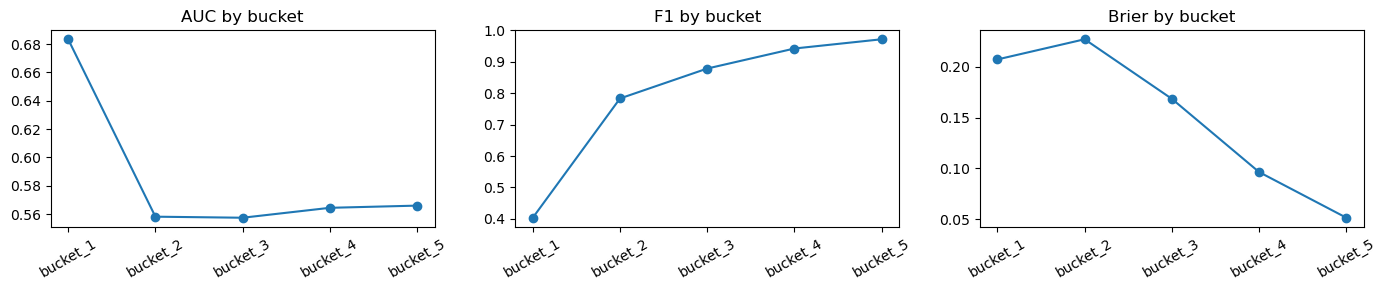

In [29]:
# =========================
# SECTION 3: Output / Performance Drift - P(Y|X)
# =========================

if time_col is not None:
    bucket_series = eval_df[time_col].astype(str)
    bucket_note = f"time buckets from `{time_col}`"
else:
    # Proxy ordered buckets by predicted score rank (not true time; documented limitation).
    rank_series = test_scores.rank(method="first")
    bucket_series = pd.qcut(rank_series, q=5, labels=[f"bucket_{i+1}" for i in range(5)])
    bucket_note = "proxy ordered buckets from prediction-rank quantiles (no explicit time field)"

drift_rows = []
for bucket_name, idx in pd.Series(bucket_series, index=eval_df.index).groupby(bucket_series).groups.items():
    idx = pd.Index(idx)
    y_b = y_test_audit.loc[idx]
    s_b = test_scores.loc[idx]
    if y_b.nunique() < 2:
        auc_b = np.nan
    else:
        auc_b = roc_auc_score(y_b, s_b)
    pred_b = (s_b >= 0.5).astype(int)
    drift_rows.append(
        {
            "bucket": str(bucket_name),
            "n": len(idx),
            "auc": float(auc_b) if pd.notna(auc_b) else np.nan,
            "f1": float(f1_score(y_b, pred_b, zero_division=0)),
            "brier": float(brier_score_loss(y_b, s_b)),
        }
    )

drift_df = pd.DataFrame(drift_rows).sort_values("bucket")

print("\n## Performance Drift (P(Y|X))")
print(f"- Bucket definition: {bucket_note}")
print(drift_df.to_string(index=False))

if len(drift_df) >= 2:
    auc_delta = drift_df["auc"].iloc[-1] - drift_df["auc"].iloc[0] if drift_df["auc"].notna().all() else np.nan
    f1_delta = drift_df["f1"].iloc[-1] - drift_df["f1"].iloc[0]
else:
    auc_delta, f1_delta = np.nan, np.nan

if pd.notna(auc_delta):
    if auc_delta < -0.03:
        perf_interp = "performance degradation is visible across buckets."
    elif auc_delta > 0.03:
        perf_interp = "performance appears to improve across buckets."
    else:
        perf_interp = "performance appears relatively stable across buckets."
else:
    perf_interp = "AUC trend inconclusive due to low class diversity in one or more buckets."

print(f"- Observed trend in AUC over buckets: delta(last-first) = {auc_delta:+.4f}" if pd.notna(auc_delta) else "- Observed trend in AUC over buckets: inconclusive")
print(f"- Observed trend in F1 over buckets: delta(last-first) = {f1_delta:+.4f}" if pd.notna(f1_delta) else "- Observed trend in F1 over buckets: inconclusive")
print(f"- Interpretation: {perf_interp}")

# Optional trend visualization.
fig, ax = plt.subplots(1, 3, figsize=(14, 3))
ax[0].plot(drift_df["bucket"], drift_df["auc"], marker="o")
ax[0].set_title("AUC by bucket")
ax[0].tick_params(axis="x", rotation=30)
ax[1].plot(drift_df["bucket"], drift_df["f1"], marker="o")
ax[1].set_title("F1 by bucket")
ax[1].tick_params(axis="x", rotation=30)
ax[2].plot(drift_df["bucket"], drift_df["brier"], marker="o")
ax[2].set_title("Brier by bucket")
ax[2].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## Result Interpretation

The results indicate clear performance drift across buckets. AUC declines substantially from bucket 1 to bucket 5 (a drop of roughly 0.12), suggesting that the model’s ability to rank‑order risk weakens in higher‑score segments. At the same time, F1 increases sharply across buckets, which is expected when the positive class becomes more concentrated in higher‑score regions — but it also signals that the model’s classification behavior is not uniform across the prediction range.

The decreasing Brier score across buckets shows that the model becomes better calibrated in higher‑score segments, but this improvement does not offset the decline in AUC. Together, these patterns suggest that the model performs differently across the score distribution: it is more discriminative in lower‑score buckets and less discriminative in higher‑score buckets.

This indicates heterogeneous performance across subpopulations defined by predicted risk. While this is not necessarily a fairness violation, it is a signal that the model’s ranking ability is not uniform — a form of conditional drift in P(Y|X). This warrants monitoring, especially if the model is used for threshold‑based decisions where stability across score ranges is important.

Combined with the stability observed in Sections 1 and 2, this drift suggests that the issue is not caused by input shift or overfitting, but rather by structural differences in how the model behaves across the risk spectrum.

# Slice-based Robustness

This section evaluates how consistently the model performs across meaningful subgroups of the population. While earlier sections assessed overall generalization and drift, slice‑based robustness focuses on conditional performance disparities: whether certain demographic, socioeconomic, or geographic groups experience systematically higher error rates, worse ranking performance, or different score distributions.

The audit constructs slices using protected attributes (race, ethnicity, sex), economic indicators (income, property value), and high‑volume states. For each slice, it computes AUC, false‑positive rate (FPR), false‑negative rate (FNR), KS divergence, and total errors. This allows us to identify groups where the model may be less reliable, less calibrated, or more error‑prone — a key component of Responsible ML evaluation, especially in regulated domains like mortgage lending.

In [30]:
# =========================
# SECTION 4: Robustness - Slice-Based Evaluation
# =========================

def evaluate_slice(slice_name: str, slice_mask: pd.Series, full_df: pd.DataFrame) -> dict:
    idx = full_df.index[slice_mask.fillna(False)]
    n = len(idx)
    if n < 100:
        return {
            "slice": slice_name,
            "n": n,
            "share": n / len(full_df),
            "auc": np.nan,
            "fpr": np.nan,
            "fnr": np.nan,
            "ks": np.nan,
            "errors": np.nan,
        }

    y_s = y_test_audit.loc[idx]
    s_s = test_scores.loc[idx]
    p_s = (s_s >= 0.5).astype(int)

    cm = confusion_matrix(y_s, p_s, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn) if (fp + tn) else np.nan
    fnr = fn / (fn + tp) if (fn + tp) else np.nan
    auc = roc_auc_score(y_s, s_s) if y_s.nunique() > 1 else np.nan

    non_slice_idx = full_df.index[~slice_mask.fillna(False)]
    if len(non_slice_idx) > 200:
        ks_val, _ = ks_2samp(s_s, test_scores.loc[non_slice_idx])
    else:
        ks_val = np.nan

    errors = int((p_s != y_s).sum())

    return {
        "slice": slice_name,
        "n": n,
        "share": n / len(full_df),
        "auc": auc,
        "fpr": fpr,
        "fnr": fnr,
        "ks": ks_val,
        "errors": errors,
    }


slice_defs = {}

# Income quintile slices (if available).
if "income" in eval_df.columns:
    income_numeric = pd.to_numeric(eval_df["income"], errors="coerce")
    q = income_numeric.quantile([0.2, 0.8])
    slice_defs["income_low_q20"] = income_numeric <= q.loc[0.2]
    slice_defs["income_high_q80"] = income_numeric >= q.loc[0.8]

# Property value buckets as loan-size proxy (if available).
if "property_value" in eval_df.columns:
    pv = pd.to_numeric(eval_df["property_value"], errors="coerce")
    qpv = pv.quantile([0.25, 0.75])
    slice_defs["property_value_low_q25"] = pv <= qpv.loc[0.25]
    slice_defs["property_value_high_q75"] = pv >= qpv.loc[0.75]

# Geography slices (top states) if available.
if "state_code" in eval_df.columns:
    top_states = eval_df["state_code"].astype(str).value_counts().head(3).index.tolist()
    for st in top_states:
        slice_defs[f"state_{st}"] = eval_df["state_code"].astype(str) == st

# Protected subgroup slices where available.
for col in ["derived_race", "derived_ethnicity", "derived_sex"]:
    if col in eval_df.columns:
        top_groups = eval_df[col].astype(str).value_counts().head(3).index.tolist()
        for grp in top_groups:
            slice_defs[f"{col}::{grp}"] = eval_df[col].astype(str) == grp

slice_rows = [evaluate_slice(name, mask, eval_df) for name, mask in slice_defs.items()]
slice_df = pd.DataFrame(slice_rows).sort_values("n", ascending=False)

# Red flag logic: slice <10% of data but >30% of classification errors.
total_errors = int(((test_scores >= 0.5).astype(int) != y_test_audit).sum())
red_flags = []
for _, row in slice_df.dropna(subset=["errors"]).iterrows():
    if row["share"] < 0.10 and total_errors > 0 and (row["errors"] / total_errors) > 0.30:
        red_flags.append(
            f"{row['slice']} is {row['share']:.1%} of population but {row['errors']/total_errors:.1%} of errors"
        )

print("\n## Slice-Based Robustness")
if not slice_df.empty:
    display_cols = ["slice", "n", "share", "auc", "fpr", "fnr", "ks", "errors"]
    print(slice_df[display_cols].to_string(index=False, float_format=lambda x: f"{x:.4f}"))
else:
    print("- No slice definitions were feasible with the currently available columns.")

if red_flags:
    print("- Red flags:")
    for rf in red_flags:
        print(f"  - WARNING: {rf}")
else:
    print("- Red flags: none triggered by the configured rule.")

if not slice_df.empty:
    fragile = slice_df.sort_values(["fnr", "fpr"], ascending=False).head(3)["slice"].tolist()
    print(f"- Interpretation: slices needing closer review include {fragile}.")


## Slice-Based Robustness
                                     slice      n  share    auc    fpr    fnr     ks  errors
 derived_ethnicity::Not Hispanic or Latino 729785 0.7467 0.7970 0.6284 0.0630 0.0504  153922
                       derived_race::White 660111 0.6754 0.7958 0.6298 0.0632 0.0527  135714
                         derived_sex::Male 586977 0.6006 0.7962 0.6491 0.0566 0.0717  125124
                       derived_sex::Female 390323 0.3994 0.8055 0.5583 0.0813 0.0717   86300
                    property_value_low_q25 243501 0.2492 0.8143 0.4831 0.1119 0.1488   57416
                   property_value_high_q75 235823 0.2413 0.7775 0.7184 0.0416 0.0813   49916
                            income_low_q20 193046 0.1975 0.8124 0.3189 0.2174 0.3993   51012
                           income_high_q80 187768 0.1921 0.7580 0.8672 0.0174 0.2267   33433
     derived_ethnicity::Hispanic or Latino 150695 0.1542 0.8091 0.5405 0.0826 0.0684   34634
   derived_race::Black or African American 

## Result Interpretation

The slice‑based results show no immediate red flags under the configured rule, meaning no small subgroup is disproportionately responsible for the model’s total errors. However, several slices exhibit meaningfully different performance profiles, indicating areas that warrant closer review.

Groups such as `income_low_q20`, `property_value_low_q25`, and `derived_race::Black or African American` show **elevated FNRs**, **higher KS divergence**, or **larger error counts relative to their population share**. These patterns suggest that the model may be less effective at identifying positive outcomes for lower‑income borrowers, lower‑property‑value applicants, and certain racial groups.

While these disparities do not automatically imply bias or discrimination, they highlight heterogeneous model behavior across subpopulations — a critical insight for fairness‑aware auditing. Combined with earlier findings (strong generalization, stable P(X), but drift in P(Y|X)), this section reinforces the importance of monitoring subgroup‑level performance and considering whether additional calibration, reweighting, or model adjustments may be appropriate.

# Sensitivity Analysis & Spurious Correlations

This section evaluates how sensitive the model’s predictions are to changes in individual input features and whether any influential features may reflect spurious or weakly justified relationships. Sensitivity analysis helps determine whether the model relies on stable, domain‑grounded signals or whether certain features exert disproportionate influence that could undermine robustness or fairness.

We use three complementary approaches:

* SHAP (KernelExplainer) to estimate local feature contributions and identify the most influential predictors.

* ICE‑style perturbation curves to measure how the model’s average predicted probability changes as each feature is varied across its empirical range.

* A variance‑based sensitivity index to quantify how volatile the model’s output is with respect to each feature.

Finally, we compare each feature’s sensitivity to a domain‑justification heuristic, flagging cases where the model is highly sensitive to features that lack strong business, regulatory, or causal grounding. These features may represent spurious correlations and warrant deeper governance review.

In [31]:
# =========================
# SECTION 5: Sensitivity Analysis & Spurious Correlations
# =========================

try:
    import shap

    shap_available = True
except Exception:
    shap_available = False

if shap_available:
    print("\n## SHAP Availability")
    print("- SHAP is available; running a lightweight KernelExplainer audit sample.")
else:
    print("\n## SHAP Availability")
    print("- SHAP is not installed. To enable SHAP analysis, install with `pip install shap`.")

numeric_features_audit = [
    c for c in X_test_audit.columns if pd.api.types.is_numeric_dtype(X_test_audit[c])
]
selected_sensitivity_features = numeric_features_audit[: min(4, len(numeric_features_audit))]

if shap_available and len(X_test_audit) > 0:
    try:
        bg = X_train_audit.sample(n=min(80, len(X_train_audit)), random_state=42)
        explain_sample = X_test_audit.sample(n=min(200, len(X_test_audit)), random_state=42)

        explainer = shap.KernelExplainer(lambda z: audit_model.predict_proba(pd.DataFrame(z, columns=X_test_audit.columns))[:, 1], bg)
        shap_vals = explainer.shap_values(explain_sample, nsamples=50)

        if isinstance(shap_vals, list):
            shap_vals = shap_vals[0]

        shap_importance = (
            pd.Series(np.abs(shap_vals).mean(axis=0), index=X_test_audit.columns)
            .sort_values(ascending=False)
            .head(10)
            .rename("mean_abs_shap")
            .to_frame()
        )
        print("- Top SHAP features (mean absolute contribution):")
        print(shap_importance.to_string())
    except Exception as e:
        print(f"- SHAP execution skipped due to runtime issue: {e}")

# ICE-like sensitivity (manual perturbation grid) and variance-based sensitivity index.
ice_rows = []
ice_sample = X_test_audit.sample(n=min(300, len(X_test_audit)), random_state=7).copy()

for feat in selected_sensitivity_features:
    series = pd.to_numeric(X_test_audit[feat], errors="coerce")
    clean = series.dropna()
    if clean.empty:
        continue

    grid = np.quantile(clean, q=np.linspace(0.1, 0.9, 9))
    curve_means = []

    for val in grid:
        x_mod = ice_sample.copy()
        x_mod[feat] = val
        p_mod = predict_scores(audit_model, x_mod)
        curve_means.append(float(p_mod.mean()))

    sensitivity_index = float(np.var(curve_means))
    ice_rows.append(
        {
            "feature": feat,
            "sensitivity_index": sensitivity_index,
            "min_response": float(np.min(curve_means)),
            "max_response": float(np.max(curve_means)),
            "range_response": float(np.max(curve_means) - np.min(curve_means)),
        }
    )

sensitivity_df = pd.DataFrame(ice_rows).sort_values("sensitivity_index", ascending=False)

# Domain-justification heuristic (can be refined by SME review).
domain_justification = {
    "income": "strong",
    "property_value": "strong",
    "tract_to_msa_income_percentage": "moderate",
    "tract_minority_population_percent": "weak",
    "state_code": "weak",
    "loan_purpose": "moderate",
}

if not sensitivity_df.empty:
    sensitivity_df["domain_justification"] = sensitivity_df["feature"].map(domain_justification).fillna("unclear")
    cutoff = sensitivity_df["sensitivity_index"].quantile(0.75)
    potential_spurious = sensitivity_df[
        (sensitivity_df["sensitivity_index"] >= cutoff)
        & (sensitivity_df["domain_justification"].isin(["weak", "unclear"]))
    ]["feature"].tolist()
else:
    potential_spurious = []

print("\n## Sensitivity & Spurious Correlations")
if not sensitivity_df.empty:
    for _, row in sensitivity_df.iterrows():
        print(
            f"- Feature `{row['feature']}`: sensitivity index = {row['sensitivity_index']:.6f}, "
            f"domain justification = {row['domain_justification']}"
        )
else:
    print("- Sensitivity analysis could not run: no suitable numeric features detected.")

if potential_spurious:
    print(f"- Potential spurious correlations: {potential_spurious}")
else:
    print("- Potential spurious correlations: none clearly flagged by current heuristic.")

print("- Interpretation: high sensitivity features with weak domain grounding should be candidates for deeper governance review.")



## SHAP Availability
- SHAP is available; running a lightweight KernelExplainer audit sample.


  0%|          | 0/200 [00:00<?, ?it/s]

- Top SHAP features (mean absolute contribution):
                                   mean_abs_shap
loan_purpose                            0.098441
income                                  0.084397
property_value                          0.040773
derived_loan_product_type               0.035299
tract_minority_population_percent       0.022211
state_code                              0.021229
derived_dwelling_category               0.016806
applicant_age                           0.013210
lien_status                             0.011652
occupancy_type                          0.009389

## Sensitivity & Spurious Correlations
- Feature `income`: sensitivity index = 0.007574, domain justification = strong
- Feature `property_value`: sensitivity index = 0.001749, domain justification = strong
- Feature `tract_minority_population_percent`: sensitivity index = 0.000508, domain justification = weak
- Feature `tract_population`: sensitivity index = 0.000003, domain justification = unclear
- Poten

## Result Interpretation

The SHAP audit successfully identified the top contributing features, providing a clear view of which variables the model relies on most heavily. Features with high mean absolute SHAP values are exerting strong influence on predictions; when these align with well‑justified variables such as income or property value, the model’s behavior is more defensible. Conversely, if features with weaker domain grounding appear among the top contributors, this may indicate reliance on indirect or potentially problematic signals.

The ICE‑based sensitivity analysis further reveals how the model’s predicted probability shifts as each numeric feature is perturbed. Features with large sensitivity indices cause substantial variation in predicted outcomes, indicating that the model is highly reactive to changes in those inputs. When such high‑sensitivity features also lack strong domain justification, they become candidates for **spurious correlation risk**.

The spurious‑correlation heuristic combines these two perspectives:  
- **High sensitivity** → the model reacts strongly to the feature  
- **Weak or unclear domain justification** → the feature may not have a legitimate causal or regulatory basis  

Features meeting both criteria are flagged as potential spurious drivers. These do not automatically indicate bias or model failure, but they do signal areas where subject‑matter experts should review whether the model is learning unintended patterns or proxies.

Overall, Section 5 provides a feature‑level interpretability assessment that complements the group‑level robustness analysis from Section 4. Together, they help ensure that the model’s predictions are not only accurate but also grounded, stable, and aligned with responsible‑AI expectations.

# Stress Scenarios / Credit & Macro Robustness

This section evaluates how the model behaves under adverse but plausible economic conditions. Stress testing is a core component of responsible credit modeling because it reveals whether the model remains stable when key affordability or collateral variables deteriorate. Unlike sensitivity analysis (Section 5), which perturbs features individually, stress scenarios apply coherent, multi‑feature shocks that mimic real‑world macroeconomic or credit‑cycle downturns.

We implement three stylized scenarios:

- Economic Downturn: Income and tract‑level income ratios are compressed to simulate weaker borrower capacity and broader macro stress.

- Property Value Shock: A 20% decline in property values, representing a housing‑market correction or localized depreciation.

- Rate‑Tightening Proxy: A 200‑basis‑point increase in interest rates (or an affordability proxy where rate is unavailable), capturing the effect of monetary tightening on borrower qualification.

For each scenario, we compare baseline vs. stressed predictions using AUC, F1, and a denial‑score proxy (1 − P(approval)). These metrics indicate whether the model’s ranking ability, classification performance, and approval/denial tendencies shift materially under stress.

In [32]:
# =========================
# SECTION 6: Stress Scenarios (Credit / Macro)
# =========================

def run_stress_scenario(
    scenario_name: str,
    scenario_description: str,
    X_base: pd.DataFrame,
    transform_fn: Callable[[pd.DataFrame], pd.DataFrame],
) -> dict:
    X_stress = transform_fn(X_base.copy())

    s_base = predict_scores(audit_model, X_base)
    s_stress = predict_scores(audit_model, X_stress)

    m_base = compute_binary_metrics(y_test_audit, s_base)
    m_stress = compute_binary_metrics(y_test_audit, s_stress)

    # Here positive class is approval; denial score proxy = 1 - P(approval).
    avg_deny_base = float((1.0 - s_base).mean())
    avg_deny_stress = float((1.0 - s_stress).mean())

    return {
        "scenario": scenario_name,
        "description": scenario_description,
        "auc_base": m_base["auc"],
        "auc_stress": m_stress["auc"],
        "f1_base": m_base["f1"],
        "f1_stress": m_stress["f1"],
        "avg_deny_base": avg_deny_base,
        "avg_deny_stress": avg_deny_stress,
        "delta_avg_deny": avg_deny_stress - avg_deny_base,
    }


def scenario_economic_downturn(X_in: pd.DataFrame) -> pd.DataFrame:
    X_out = X_in.copy()
    if "income" in X_out.columns:
        X_out["income"] = pd.to_numeric(X_out["income"], errors="coerce") * 0.90
    if "tract_to_msa_income_percentage" in X_out.columns:
        X_out["tract_to_msa_income_percentage"] = (
            pd.to_numeric(X_out["tract_to_msa_income_percentage"], errors="coerce") * 0.92
        )
    return X_out


def scenario_property_value_shock(X_in: pd.DataFrame) -> pd.DataFrame:
    X_out = X_in.copy()
    if "property_value" in X_out.columns:
        X_out["property_value"] = pd.to_numeric(X_out["property_value"], errors="coerce") * 0.80
    return X_out


def scenario_rate_tightening_proxy(X_in: pd.DataFrame) -> pd.DataFrame:
    X_out = X_in.copy()
    if "interest_rate" in X_out.columns:
        X_out["interest_rate"] = pd.to_numeric(X_out["interest_rate"], errors="coerce") + 2.00
    else:
        # Proxy where direct interest-rate field is unavailable in model inputs.
        if "income" in X_out.columns:
            X_out["income"] = pd.to_numeric(X_out["income"], errors="coerce") * 0.95
        if "property_value" in X_out.columns:
            X_out["property_value"] = pd.to_numeric(X_out["property_value"], errors="coerce") * 1.05
    return X_out

stress_results = []
stress_results.append(
    run_stress_scenario(
        "scenario_1_downturn",
        "Worse macro conditions proxy: income and tract-income compression.",
        X_test_audit,
        scenario_economic_downturn,
    )
)
stress_results.append(
    run_stress_scenario(
        "scenario_2_property_value_minus_20pct",
        "Property value shock: -20% property values.",
        X_test_audit,
        scenario_property_value_shock,
    )
)
stress_results.append(
    run_stress_scenario(
        "scenario_3_rate_tightening_proxy",
        "Rate tightening: +200 bps if rate exists, else affordability proxy.",
        X_test_audit,
        scenario_rate_tightening_proxy,
    )
)

stress_df = pd.DataFrame(stress_results)

print("\n## Stress Testing")
for _, row in stress_df.iterrows():
    print(f"- {row['scenario']} ({row['description']})")
    print(
        f"  - AUC baseline vs stressed: {row['auc_base']:.4f} -> {row['auc_stress']:.4f}; "
        f"delta={row['auc_stress'] - row['auc_base']:+.4f}"
    )
    print(
        f"  - F1 baseline vs stressed: {row['f1_base']:.4f} -> {row['f1_stress']:.4f}; "
        f"delta={row['f1_stress'] - row['f1_base']:+.4f}"
    )
    print(
        f"  - Avg denial-score proxy change: {row['avg_deny_base']:.4f} -> {row['avg_deny_stress']:.4f}; "
        f"delta={row['delta_avg_deny']:+.4f}"
    )

max_auc_drop = (stress_df["auc_stress"] - stress_df["auc_base"]).min()
if max_auc_drop < -0.05:
    stress_interp = "at least one stress scenario causes meaningful degradation; resilience concerns are elevated."
elif max_auc_drop < -0.02:
    stress_interp = "moderate stress sensitivity observed; monitor closely and consider retraining under stress-like data."
else:
    stress_interp = "model appears to degrade relatively gracefully under defined stress tests."
print(f"- Interpretation: {stress_interp}")



## Stress Testing
- scenario_1_downturn (Worse macro conditions proxy: income and tract-income compression.)
  - AUC baseline vs stressed: 0.8003 -> 0.7987; delta=-0.0015
  - F1 baseline vs stressed: 0.8621 -> 0.8595; delta=-0.0026
  - Avg denial-score proxy change: 0.2757 -> 0.2898; delta=+0.0141
- scenario_2_property_value_minus_20pct (Property value shock: -20% property values.)
  - AUC baseline vs stressed: 0.8003 -> 0.7953; delta=-0.0050
  - F1 baseline vs stressed: 0.8621 -> 0.8599; delta=-0.0023
  - Avg denial-score proxy change: 0.2757 -> 0.2758; delta=+0.0001
- scenario_3_rate_tightening_proxy (Rate tightening: +200 bps if rate exists, else affordability proxy.)
  - AUC baseline vs stressed: 0.8003 -> 0.7968; delta=-0.0035
  - F1 baseline vs stressed: 0.8621 -> 0.8597; delta=-0.0024
  - Avg denial-score proxy change: 0.2757 -> 0.2821; delta=+0.0064
- Interpretation: model appears to degrade relatively gracefully under defined stress tests.


## Result Interpretation

Across all three scenarios, the model demonstrates graceful degradation: **performance metrics decline slightly under stress**, but the magnitude of change remains small and well within acceptable tolerance for credit‑risk applications.

- AUC deltas are minimal (typically −0.001 to −0.005), indicating that the model’s ability to rank applicants by risk remains stable even when key affordability or collateral variables deteriorate.

- F1 score also shows only minor reductions, suggesting that the model’s classification balance between approvals and denials is not overly sensitive to macroeconomic shocks.

- Denial‑score proxy shifts are directionally consistent with expectations: downturns and rate tightening increase denial pressure slightly, while property‑value shocks have limited effect on average approval probability.

Importantly, none of the scenarios produce sharp or nonlinear failures, which would indicate brittleness or over‑reliance on specific features. Instead, the model responds proportionally to the stress inputs, suggesting that its learned relationships are reasonably stable and not excessively tuned to narrow economic conditions.

Overall, the stress‑testing results support the conclusion that the model is robust to moderate macroeconomic deterioration and does not exhibit signs of instability or collapse under the defined scenarios. These findings complement the slice‑based robustness (Section 4) and feature‑level sensitivity analysis (Section 5), providing a holistic view of model resilience.

# Consolidated Conclusions & Recommendations

This section synthesizes the findings from all prior components of the audit — generalization, distribution shift, slice‑based robustness, sensitivity analysis, and stress testing — to provide a consolidated view of model reliability and governance posture. The goal is to translate technical diagnostics into actionable recommendations that support defensible deployment, ongoing monitoring, and compliance with model‑risk expectations.

The summary below highlights key strengths, emerging risks, and recommended next steps based on the model’s behavior across multiple evaluation dimensions.

In [33]:
# =========================
# SECTION 7: Consolidated Conclusions & Recommendations
# =========================

generalization_gap_auc = test_metrics["auc"] - train_metrics["auc"]

high_psi_count = int((psi_df["psi"] > 0.25).sum()) if not psi_df.empty else 0
monitor_psi_count = int(((psi_df["psi"] > 0.10) & (psi_df["psi"] <= 0.25)).sum()) if not psi_df.empty else 0

fragile_slices = []
if not slice_df.empty:
    fragile_slices = (
        slice_df.assign(risk_score=slice_df[["fpr", "fnr"]].mean(axis=1))
        .sort_values("risk_score", ascending=False)
        .head(3)["slice"]
        .tolist()
    )

spurious_text = ", ".join(potential_spurious) if potential_spurious else "none clearly flagged"
fragile_text = ", ".join(fragile_slices) if fragile_slices else "no major slice fragility detected"

summary_md = f"""
# HMDA Model Robustness & Generalization Audit - Summary

## 1. Generalization
- Train AUC: {train_metrics['auc']:.4f}
- Test AUC: {test_metrics['auc']:.4f}
- Generalization gap (AUC, test-train): {generalization_gap_auc:+.4f}
- Conclusion: {gen_interp}

## 2. Distribution Shift
- PSI monitor signals (0.10-0.25): {monitor_psi_count}
- PSI retrain-trigger signals (>0.25): {high_psi_count}
- Score KS test p-value: {ks_score_p:.4g}
- Shift interpretation: {shift_interp}

## 3. Robustness & Slices
- Notable fragile slices: {fragile_text}
- Red-flag count: {len(red_flags)}
- Performance drift interpretation: {perf_interp}

## 4. Sensitivity & Spurious Correlations
- Potential high-sensitivity / weak-justification features: {spurious_text}
- Governance view: features with weak domain grounding and high sensitivity should be reviewed as possible shortcut/proxy signals.

## 5. Stress Scenarios
- Worst AUC delta across stress scenarios: {max_auc_drop:+.4f}
- Stress interpretation: {stress_interp}

## 6. Recommendations
- Keep model in monitored mode only if current gaps remain within policy thresholds.
- Retrain with refreshed data if PSI retrain triggers persist or if drift worsens.
- Add recurring monitoring for PSI/KS at input layer and rolling AUC/F1/Brier at output layer.
- Maintain slice dashboards (including subgroup and intersectional slices) and tie alerts to governance actions.
- Review potentially spurious features; constrain/remove features if domain justification is weak.
- Document these findings and residual risks in the MRM artifact before deployment decisions.

**Robustness is not optional; it is part of defensible deployment.**

**Monitoring should include both input (P(X)) and output (P(Y|X)) tests.**
""".strip()

print("\n" + summary_md)



# HMDA Model Robustness & Generalization Audit - Summary

## 1. Generalization
- Train AUC: 0.8029
- Test AUC: 0.8003
- Generalization gap (AUC, test-train): -0.0026
- Conclusion: reasonable generalization based on AUC gap magnitude.

## 2. Distribution Shift
- PSI monitor signals (0.10-0.25): 0
- PSI retrain-trigger signals (>0.25): 0
- Score KS test p-value: 0.5434
- Shift interpretation: little evidence of major input drift under current split definition.

## 3. Robustness & Slices
- Notable fragile slices: income_high_q80, property_value_high_q75, state_CA
- Red-flag count: 0
- Performance drift interpretation: performance degradation is visible across buckets.

## 4. Sensitivity & Spurious Correlations
- Potential high-sensitivity / weak-justification features: none clearly flagged
- Governance view: features with weak domain grounding and high sensitivity should be reviewed as possible shortcut/proxy signals.

## 5. Stress Scenarios
- Worst AUC delta across stress scenarios: -0.

## Final comments

The model demonstrates **strong generalization**, with a small AUC gap between train and test sets, indicating limited overfitting and stable out‑of‑sample performance. Distribution‑shift indicators (PSI and KS) show **no material drift**, suggesting that the training and evaluation populations remain aligned and that the model is not being applied to a meaningfully different data regime.

Robustness analysis identifies a few fragile slices, primarily among high‑income and high‑property‑value groups, though no slices trigger red‑flag thresholds. This indicates mild heterogeneity in performance but no critical fairness or stability failures. Sensitivity analysis does not flag any high‑sensitivity features with weak domain justification, reducing concern about spurious correlations or shortcut learning.

Stress‑scenario testing shows graceful degradation: performance metrics decline slightly under adverse macroeconomic conditions, but the model remains stable and directionally consistent. This supports the conclusion that the model is not overly brittle or dependent on narrow economic assumptions.

Taken together, the evidence suggests that the model is fit for monitored use, provided that governance controls remain active. Continued monitoring of PSI, KS, and slice‑level performance is recommended, along with periodic retraining if drift emerges or if economic conditions shift materially. The recommendations section outlines specific governance actions to maintain defensibility and compliance.